In [1]:
import os
import json
import random
import math
import pandas as pd
import numpy as np
import scipy as sp
import pylab as plt
import seaborn as sns
import matplotlib as mpl
from tqdm import tqdm
from collections import Counter

In [2]:
%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [3]:
plt.style.use("../src/mpl_style.txt")

In [4]:
import jupyter_black
jupyter_black.load()

In [5]:
BASELINE_NAME = "baseline_2026-01-23"
VERSION = "research-article_aimrd_f"
DATA_PATH = os.path.join("../data", BASELINE_NAME, "formatted")
RESULTS_PATH = os.path.join("../data/results", BASELINE_NAME, VERSION)
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
colors = dict(zip(sections, sns.color_palette("colorblind", len(sections))))
# change full color to make it less similar to introduction
colors["full"] = (0.541, 0.365, 0.224)

#### Overview for number of papers per month / year

In [6]:
# total papers before preprocessing
with open(os.path.join(DATA_PATH, "paper_counts.json")) as f:
    paper_count = json.load(f)

In [7]:
total = 0
for p in paper_count.values():
    total += p["before_prep"]
total

7125722

In [8]:
total = 0
for p in paper_count.values():
    total += p["after_prep"]
total

5757823

In [9]:
with open(os.path.join(RESULTS_PATH, "filters.json")) as f:
    filters = json.load(f)

dates = pd.to_datetime(filters["all_dates"])
len(dates)

1602404

In [10]:
dates = dates[dates.year >= 2010]
len(dates)

1566414

In [11]:
dates = dates[dates.year >= 2017]
len(dates)

1194287

mean number of papers per month: 11058.212962962964


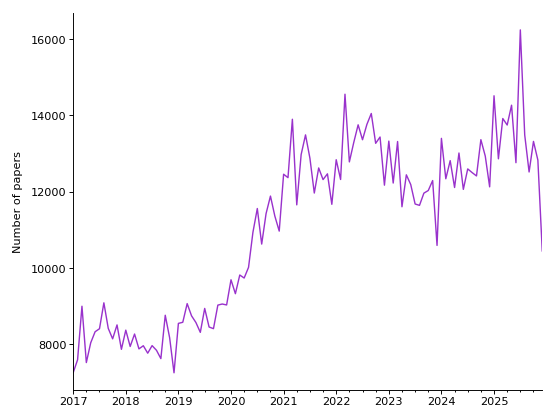

In [12]:
counts = pd.Series(1, index=dates).groupby(dates.to_period("M")).sum()
print(f"mean number of papers per month: {counts.mean()}")
fig = plt.figure(figsize=(4, 3), layout="constrained")
counts.plot(color="darkorchid")
plt.ylabel("Number of papers")

plt.savefig(
    os.path.join("../results/plots/", BASELINE_NAME, "papers_per_month.png"),
    dpi=300,
)

#### Overview of countries

In [7]:
with open(os.path.join(RESULTS_PATH, "filters.json")) as f:
    filters = json.load(f)

In [8]:
dates = pd.to_datetime(filters["all_dates"])
countries = filters["all_countries"]

In [8]:
country_ind = np.isin(countries, ["Saudi Arabia", "Germany"])
ind = (dates.year == 2000) & country_ind
ind

array([False,  True, False, ..., False, False, False], shape=(1602404,))

In [ ]:
np.isin(countries, None)

In [9]:
np.isin(
    ["Canada", "Ireland", None, "Germany"],
    list(utils.english_speaking.keys()),
    invert=True,
) & np.isin(
    ["Canada", "Ireland", None, "Germany"],
    None,
    invert=True,
)

array([False, False, False,  True])

In [ ]:
d = {"a":1, "b":1, "c":1}
list(d.keys()) + ["d", "e"]

In [9]:
c = Counter(countries)

In [11]:
c["Korea, Republic of"]

31654

In [18]:
country_ind = np.isin(countries, ["Korea, Republic of"])
ind = (dates.year >= 2017) & country_ind
sum(ind)

np.int64(25537)

In [ ]:
country_alt_names = {
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Korea, Republic of": "South Korea",
    "Iran, Islamic Republic of": "Iran",
    "english": "NES",
    "non-english": "NNES",
}

In [19]:
countries_in_order = [
    "Korea, Republic of",
    "China",
    "Taiwan",
    "Iran, Islamic Republic of",
    "Spain",
    "India",
    "Switzerland",
    "Brazil",
    "Italy",
    "Japan",
    "Germany",
    "Netherlands",
    "Sweden",
    "Canada",
    "Australia",
    "France",
    "United States of America",
    "United Kingdom of Great Britain and Northern Ireland",
    "NES",
    "NNES",
]

In [28]:
country_counts = {}
for country in countries_in_order:
    if country == "NES":
        country_ind = np.isin(countries, list(utils.english_speaking.keys()))
    elif country == "NNES":
        country_ind = np.isin(countries, None, invert=True) & np.isin(
            countries, list(utils.english_speaking.keys()), invert=True
        )
    else:
        country_ind = np.isin(countries, country)
    ind = (dates.year >= 2017) & country_ind
    country_counts[country] = sum(ind)

In [31]:
cc_df = pd.DataFrame(
    zip(country_counts.keys(), country_counts.values()),
    columns=["country", "paper counts"],
)
cc_df = cc_df.sort_values("paper counts", ascending=False)
print(cc_df.to_latex(index=False))

\begin{tabular}{lr}
\toprule
country & paper counts \\
\midrule
NNES & 719959 \\
NES & 333161 \\
China & 246000 \\
United States of America & 208178 \\
United Kingdom of Great Britain and Northern Ireland & 64347 \\
Japan & 59863 \\
Germany & 54827 \\
Italy & 28716 \\
Canada & 28649 \\
Netherlands & 27538 \\
Korea, Republic of & 25537 \\
France & 24577 \\
Australia & 22956 \\
Spain & 22657 \\
Brazil & 19670 \\
Sweden & 16015 \\
Switzerland & 15389 \\
India & 14173 \\
Taiwan & 11001 \\
Iran, Islamic Republic of & 9399 \\
\bottomrule
\end{tabular}



Three circles of english model: Kachru, B. B. (1985). Standards, codification and sociolinguistic realism: The English language in the Outer Circle. In R. Quirk & H. G. Widdowson (Eds.), English in the world: Teaching and learning the language and literature (pp. 11–30). Cambridge University Press.: the United States, the United Kingdom and Ireland, Australia and New Zealand, South Africa, and much of Canada.

#### Overview of journals 

In [6]:
df, c1, c2 = utils.load_paper_df(
    DATA_PATH,
    "research-article",
    ["introduction", "methods", "results", "discussion"],
    subset="all",
)
len(df)

1602404

In [9]:
df = df[df["date"].apply(lambda x: x.year >= 2017)]
len(df)

1194287

In [8]:
# PloS ONE changes spelling at some point, need to fix
df["journal"] = ["PLoS ONE" if j == "PLOS ONE" else j for j in df["journal"]]
df["journal"] = [
    (
        "NAS Proceedings"
        if j
        == "Proceedings of the National Academy of Sciences of the United States of America"
        else j
    )
    for j in df["journal"]
]

In [12]:
# How many preprints in the dataset?
len(
    df[
        df["journal"].apply(
            lambda x: x in ["bioRxiv", "medRxiv", "arXiv", "Research Square"]
        )
    ]
)

22470

In [13]:
22470 / len(df)

0.01881457304651227

In [9]:
min_j = 4000
journal_counts = df["journal"].value_counts()
disc_papers = np.sum(journal_counts[journal_counts < min_j])
disc_journals = np.sum(journal_counts < min_j)
journal_counts_agg = journal_counts[journal_counts >= min_j]
journal_counts_agg.loc["other"] = disc_papers
journal_counts_agg

journal
Scientific Reports                                   96943
Nature Communications                                56321
PLoS ONE                                             46678
International Journal of Molecular Sciences          22875
Frontiers in Immunology                              18922
bioRxiv                                              16151
eLife                                                13118
NAS Proceedings                                      11717
Frontiers in Microbiology                            11340
Science Advances                                     10556
Oncotarget                                            9742
Frontiers in Oncology                                 9071
iScience                                              8971
Frontiers in Plant Science                            7855
Frontiers in Psychology                               7772
Communications Biology                                7562
Nucleic Acids Research                          

In [ ]:
disc_journals

In [ ]:
disc_papers

In [ ]:
def reorganize_colors(x: list, chunk_len: int) -> list:
    """
    chunk_len=2: [0,1,2,3,4,5] -> [0,3,1,4,2,5]
    chunk_len=3: [0,1,2,3,4,5] -> [0,2,4,1,3,5]"""

    mod = math.ceil(len(x) / chunk_len)
    x_new = [0] * len(x)
    offset = 0
    for res in range(mod):
        x_sub = [x[i] for i in range(len(x)) if (i % mod) == res]
        x_new[offset : offset + len(x_sub)] = x_sub
        offset += len(x_sub)
        print(x_new)

    return x_new

In [ ]:
reorganize_colors([0, 1, 2, 3, 4, 5, 6], 2)

In [ ]:
all_journals = list(journal_counts_agg.keys())
# cmap = mpl.colormaps["rainbow"](range(0, len(all_journals) * 7, 7))
cmap = [cs for cs in sns.color_palette("hls", len(all_journals))]
journals_colormap = dict(
    zip(
        all_journals,
        reorganize_colors(cmap, 8),
    )
)
journals_colormap["other"] = (0.5, 0.5, 0.5)

In [ ]:
fig = plt.figure(figsize=(10, 5))

# Reduce horizontal spacing
outer = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1, 2],
    wspace=0,  # << smaller gap
)

# Make left panel shorter vertically
left_gs = outer[0].subgridspec(
    nrows=3,
    ncols=1,
    height_ratios=[1, 2, 1],
)

ax_line = fig.add_subplot(left_gs[1])
ax_pie = fig.add_subplot(outer[1])

# ---- Panel a: line plot ----
counts = pd.Series(1, index=dates).groupby(dates.to_period("M")).sum()

counts.plot(
    color="darkorchid",
    ax=ax_line,
)

ax_line.set_ylabel("Number of newly added papers")
ax_line.set_ylim(0, 16500)

# Panel label
ax_line.text(
    -0.15,
    1.1,
    "a",
    transform=ax_line.transAxes,
    fontsize=10,
    fontweight="bold",
    va="top",
)

# ---- Panel b: pie chart ----
ax_pie.pie(
    journal_counts_agg,
    labels=journal_counts_agg.index,
    autopct="%1.1f%%",
    colors=[journals_colormap[key] for key in journal_counts_agg.index],
    textprops={"fontsize": 4},
    startangle=130,
    pctdistance=0.8,
    counterclock=False,
)
ax_pie.set_aspect("equal")
ax_pie.set_xlim(-1.05, 1.55)
ax_pie.set_ylim(-1.1, 1.1)

# Panel label
ax_pie.text(
    -0.05,
    1.0,
    "b",
    transform=ax_pie.transAxes,
    fontsize=10,
    fontweight="bold",
    va="top",
)

# Fine control of margins
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.95,
    bottom=0.10,
)

plt.savefig(
    os.path.join("../results/plots/", BASELINE_NAME, "papers_journals_overview.png"),
    dpi=300,
)

In [ ]:
"""
journal_counts_yearly = {}

for year in tqdm(range(2010, 2026)):
    df, c1, c2 = utils.load_paper_df(
        DATA_PATH, "research-article", sections, subset=year
    )
    journal_counts_yearly[str(year)] = {
        "journals": df["journal"].value_counts().to_dict(),
        "c1": c1,
        "c2": c2,
    }
"""

with open(os.path.join(DATA_PATH, "journal_counts.json"), "r") as f:
    journal_counts_yearly = json.load(f)

In [ ]:
all_journals = []

for year in range(2010, 2026):
    j = journal_counts_yearly[str(year)]["journals"].keys()
    all_journals += j

random.seed(0)
all_journals = list(set(all_journals))
random.shuffle(all_journals)
journals_colormap = dict(
    zip(
        all_journals,
        [cs for cs in sns.color_palette("hls", len(all_journals))],
    )
)

In [ ]:
yearly_additions = {}
yearly_big_additions = {}

for year in range(2011, 2026):
    js = journal_counts_yearly[str(year)]["journals"].keys()
    js_prev = journal_counts_yearly[str(year - 1)]["journals"].keys()
    js_new = [j for j in js if not j in js_prev]
    yearly_additions[str(year)] = js_new
    yearly_big_additions[str(year)] = [
        j for j in js_new if journal_counts_yearly[str(year)]["journals"][j] > 1
    ]

In [ ]:
yearly_removals = {}
yearly_big_removals = {}

for year in range(2011, 2026):
    js = journal_counts_yearly[str(year)]["journals"].keys()
    js_prev = journal_counts_yearly[str(year - 1)]["journals"].keys()
    js_new = [j for j in js_prev if not j in js]
    yearly_removals[str(year)] = js_new
    yearly_big_removals[str(year)] = [
        j for j in js_new if journal_counts_yearly[str(year - 1)]["journals"][j] > 1
    ]

In [ ]:
len(yearly_additions["2011"]) - len(yearly_removals["2011"])

In [ ]:
list(map(len, yearly_additions.values()))

In [ ]:
year = 2025
k = 10

print(f"{year}\nBiggest added journals:")
for i in range(k):
    j = yearly_additions[str(year)][i]
    print(f"{j} ({journal_counts_yearly[str(year)]["journals"][j]})")
print("\nBiggest removed journals:")
for i in range(k):
    j = yearly_removals[str(year)][i]
    print(f"{j} ({journal_counts_yearly[str(year-1)]["journals"][j]})")

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")


ax.plot(
    range(2011, 2026),
    list(map(len, yearly_additions.values())),
    marker="o",
    color="green",
    alpha=0.4,
    label="all added journals",
)
ax.plot(
    range(2011, 2026),
    list(map(len, yearly_big_additions.values())),
    marker="o",
    color="green",
    label="added journals with > 1 papers",
)
ax.plot(
    range(2011, 2026),
    list(map(lambda x: -len(x), yearly_removals.values())),
    marker="o",
    color="darkorange",
    alpha=0.4,
    label="all removed journals",
)
ax.plot(
    range(2011, 2026),
    list(map(lambda x: -len(x), yearly_big_removals.values())),
    marker="o",
    color="darkorange",
    label="removed journals with > 1 papers",
)
ax.legend(loc="upper left")
ax.spines["bottom"].set_position("center")
ax.set_ylim(-1500, 1500)
plt.title("Changes in Journal composition of PMC (w.r.t. the previous year)")

plt.savefig(os.path.join("../results/plots", "journal_deltas.png"), dpi=300)

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(19, 12), layout="constrained")

for i, year in enumerate(range(2010, 2026)):

    journal_counts, c1, c2 = journal_counts_yearly[str(year)].values()
    journal_counts = pd.Series(journal_counts)

    # only show journals that make up >= 1% of papers
    thr = c2 * 0.01
    disc_papers = np.sum(journal_counts[journal_counts < thr])
    disc_journals = np.sum(journal_counts < thr)
    journal_counts_agg = journal_counts[journal_counts >= thr]

    other_label = f"other ({disc_journals} journals)"
    journal_counts_agg.loc[other_label] = disc_papers
    journals_colormap[other_label] = (0.5, 0.5, 0.5)

    # determine angle of smallest fraction
    i_min = np.argmin(journal_counts_agg)
    angles = 360 * journal_counts_agg / np.sum(journal_counts_agg)
    center_angle = angles[:i_min].sum() + angles[i_min] / 2
    start_angle = -center_angle

    ax = axs.flat[i]
    ax.pie(
        journal_counts_agg,
        labels=journal_counts_agg.index,
        autopct="%.1f%%",
        pctdistance=0.9,
        colors=[journals_colormap[key] for key in journal_counts_agg.index],
        startangle=start_angle,
    )

    ax.set_title(f"Journal distribution {year}")
    ax.text(
        x=1,
        y=0.9,
        s=f"# papers before filters: {c1}\n# papers after filters: {c2}\n# journals: {len(journal_counts)}",
    )

### Section length overview

In [10]:
df_count = df[sections].copy()
for sec in sections:
    df_count[sec] = list(map(lambda x: len(x.split()), df_count[sec]))
df_count = pd.melt(df_count, ignore_index=False).reset_index()
df_count

,index,variable,value
0,1124200,abstract,209
1,1124202,abstract,144
2,1124203,abstract,163
3,1124206,abstract,107
4,1124210,abstract,248
...,...,...,...
7165717,5739319,full,9467
7165718,5739320,full,8611
7165719,5739326,full,5586
7165720,5739327,full,3215


In [8]:
df_count[df_count["variable"] == "abstract"]["value"].median()

np.float64(245.0)

In [15]:
medians = []
perc_5 = []
perc_95 = []

for sec in sections:
    medians.append(int(df_count[df_count["variable"] == sec]["value"].median()))
    perc_5.append(int(df_count[df_count["variable"] == sec]["value"].quantile(0.05)))
    perc_95.append(int(df_count[df_count["variable"] == sec]["value"].quantile(0.95)))

In [16]:
medians_df = pd.DataFrame(
    zip(sections, perc_5, medians, perc_95),
    columns=["section", "5th percentile", "median", "95th percentile"],
)
print(medians_df.to_latex(index=False))

\begin{tabular}{lrrr}
\toprule
section & 5th percentile & median & 95th percentile \\
\midrule
abstract & 148 & 248 & 449 \\
introduction & 246 & 595 & 1314 \\
methods & 433 & 1270 & 3452 \\
results & 487 & 1852 & 5354 \\
discussion & 510 & 1179 & 2284 \\
full & 2527 & 5156 & 10684 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_1180962/2635756820.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_count, x="variable", y="value", palette=colors, whis=[5, 95])


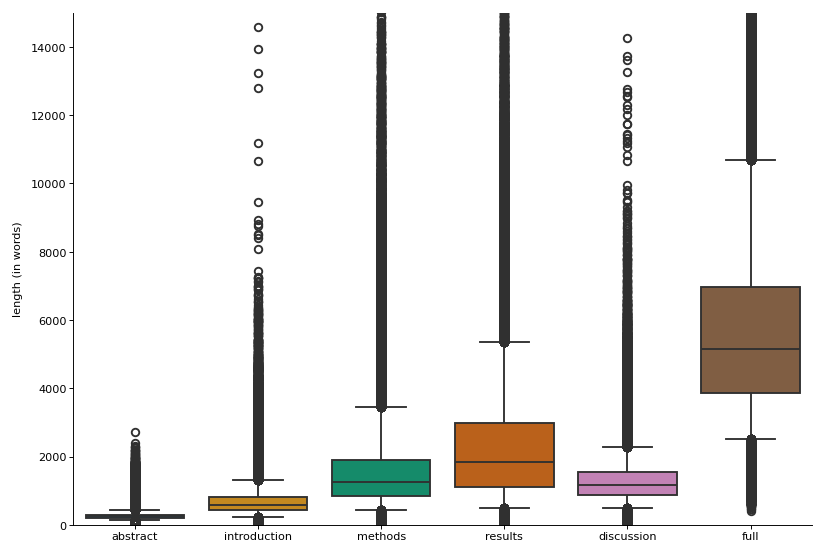

In [22]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
sns.boxplot(data=df_count, x="variable", y="value", palette=colors, whis=[5, 95])
ax.set_ylim(0, 15000)
ax.set_xlabel("")
ax.set_ylabel("length (in words)")

plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE_NAME,
        "section length.png",
    ),
    dpi=300,
)
plt.show()

### Data Availability Overview
(for the data after preprocessing, only papers from 2017 or later)
-> check for double PMC-IDs to avoid that preprint and published version both are printed

In [ ]:
df.head()

In [ ]:
for col in df.columns:
    print(f"{col}: {1 - len(df[df[col].apply(lambda x: x == None)]) / len(df)}")

In [ ]:
df[df["title"].apply(lambda x: x == None)]

In [ ]:
1 - len(df[df["country"].apply(lambda x: x == None)]) / len(df)

In [ ]:
Counter(df["pmc-id"])